# 01 - Data validation

Quick checks that the input pipeline gives the models what we expect: split files, labels, batches and augmentation.

Run `scripts/download_data.py`, `scripts/audit_data.py` and `scripts/make_splits.py` first.

In [1]:
import os, sys
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.config import COMBINED_NAMES, FRUITS, FIGURES_DIR, METADATA_CSV
from src.data_pipeline import load_split, make_dataset, build_augmenter, load_image
from src import viz
viz.apply_style()
%matplotlib inline

## 1. Split files

In [2]:
splits = {s: load_split(s) for s in ["train", "val", "test"]}
counts = pd.DataFrame({s: df["combined_name"].value_counts() for s, df in splits.items()}).loc[COMBINED_NAMES]
counts["total"] = counts.sum(axis=1)
counts.loc["TOTAL"] = counts.sum()
counts

,train,val,test,total
combined_name,,,,
Banana_fresh,699,150,150,999
Banana_spoiled,700,150,150,1000
Lemon_fresh,391,82,82,555
Lemon_spoiled,700,150,150,1000
Lulo_fresh,394,82,82,558
Lulo_spoiled,700,150,150,1000
Mango_fresh,700,150,150,1000
Mango_spoiled,700,150,150,1000
Orange_fresh,700,150,150,1000


In [3]:
meta = pd.read_csv(METADATA_CSV, keep_default_na=False)
paths = pd.concat([df["path"] for df in splits.values()])
sha = meta.set_index("path").loc[paths, "sha256"]
split_of = np.repeat(list(splits), [len(df) for df in splits.values()])
checks = {
    "files appearing in two splits": int(paths.duplicated().sum()),
    "identical images (SHA-256) in two splits": int(pd.Series(split_of, index=sha.values).groupby(level=0).nunique().gt(1).sum()),
    "groups appearing in two splits": int(pd.concat([df[["group_id"]].assign(s=s) for s, df in splits.items()]).groupby("group_id")["s"].nunique().gt(1).sum()),
    "rows with combined != fruit*2 + freshness": int(sum((df.combined_label != df.fruit_label * 2 + df.freshness_label).sum() for df in splits.values())),
}
checks

{'files appearing in two splits': 0,
 'identical images (SHA-256) in two splits': 0,
 'groups appearing in two splits': 0,
 'rows with combined != fruit*2 + freshness': 0}

## 2. A training batch with its labels

images: (16, 224, 224, 3) <dtype: 'float32'> range 0.0 - 255.0
fruit labels: (16,) <dtype: 'int32'> | freshness labels: (16,) <dtype: 'float32'>


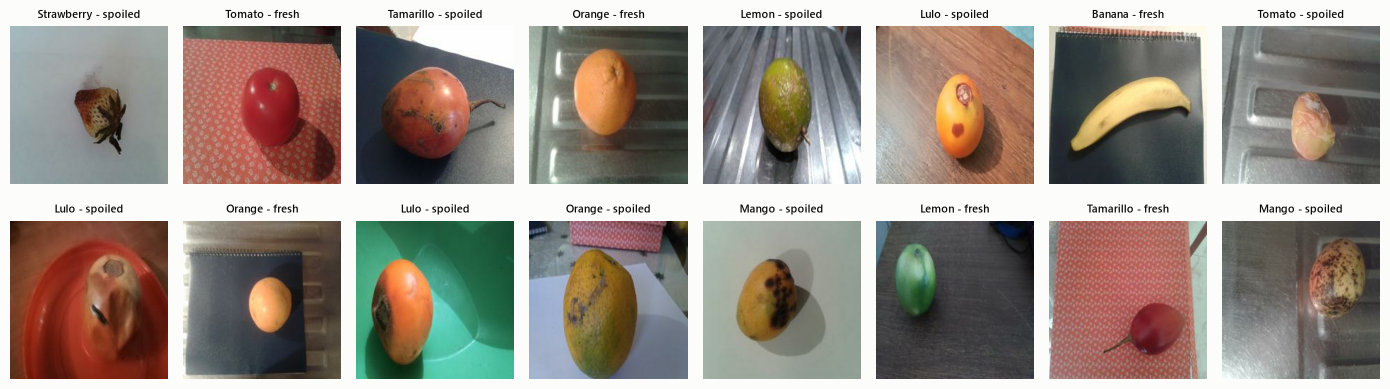

In [4]:
ds = make_dataset("train", label_mode="multitask", batch_size=16, shuffle=True, augment=False)
x, y = next(iter(ds))
print("images:", x.shape, x.dtype, "range", float(x.numpy().min()), "-", float(x.numpy().max()))
print("fruit labels:", y["fruit"].shape, y["fruit"].dtype, "| freshness labels:", y["freshness"].shape, y["freshness"].dtype)
fig, axes = plt.subplots(2, 8, figsize=(14, 4.2))
for ax, img, f, s in zip(axes.ravel(), x.numpy(), y["fruit"].numpy(), y["freshness"].numpy()):
    ax.imshow(img.astype("uint8")); ax.axis("off")
    ax.set_title(f"{FRUITS[f]} - {'spoiled' if s else 'fresh'}", fontsize=8)
plt.tight_layout(); plt.show()

The titles come from the label tensors and match the pictures. Model 1 uses the combined label (`fruit * 2 + freshness`) of the same rows.

In [5]:
xc, yc = next(iter(make_dataset("val", label_mode="combined", batch_size=8, limit=1)))
print([COMBINED_NAMES[int(c)] for c in yc.numpy()])

['Banana_fresh', 'Lemon_fresh', 'Lulo_fresh', 'Mango_fresh', 'Orange_fresh', 'Strawberry_fresh', 'Tamarillo_fresh', 'Tomato_fresh']


## 3. Augmentation (training split only)

One image sent through the augmentation layers eight times: flips, rotation up to 36 degrees, zoom, brightness and contrast changes of up to 15 %. Hue is not changed because browning and dark spots are signs of spoilage.

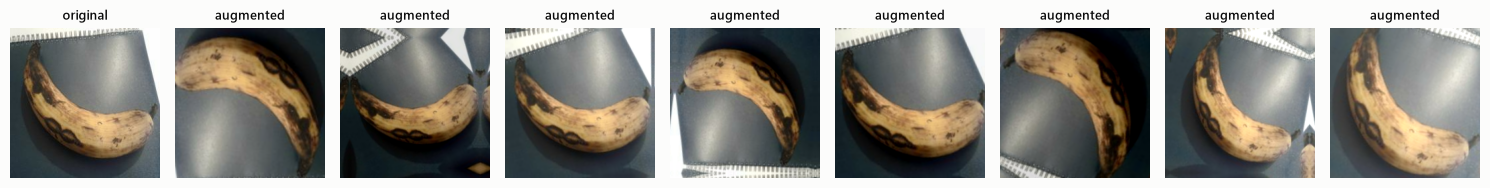

In [6]:
augmenter = build_augmenter()
sample = splits["train"].query("combined_name == 'Banana_spoiled'").iloc[0]
img = load_image(os.path.join("..", sample.path))[None]
fig, axes = plt.subplots(1, 9, figsize=(15, 2.3))
axes[0].imshow(img[0].astype("uint8")); axes[0].set_title("original", fontsize=9)
for ax in axes[1:]:
    ax.imshow(np.clip(augmenter(img, training=True)[0].numpy(), 0, 255).astype("uint8")); ax.set_title("augmented", fontsize=9)
for ax in axes: ax.axis("off")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "augmentation_examples.png")
plt.show()

In [7]:
val_batch = next(iter(make_dataset("val", batch_size=8, limit=1)))[0].numpy()
val_again = next(iter(make_dataset("val", batch_size=8, limit=1)))[0].numpy()
print("validation batches identical across two reads (no augmentation, fixed order):", np.array_equal(val_batch, val_again))

validation batches identical across two reads (no augmentation, fixed order): True


## 4. Normalisation is done inside the models

The pipeline returns raw pixels in [0, 255] and the first layer of each model rescales them, so a saved model can be used on any RGB image.

In [8]:
from src.models import build_model
for name, kwargs in [("simple_cnn", {}), ("multitask_cnn", {}), ("transfer", {"weights": None})]:
    m = build_model(name, **kwargs)
    first = [l for l in m.layers if l.__class__.__name__ == "Rescaling"][0]
    print(f"{m.name:22s} first layer {first.name:26s} scale={first.scale:.6f} offset={first.offset}")

model1_simple_cnn      first layer rescale                    scale=0.003922 offset=0.0


model2_multitask_cnn   first layer rescale                    scale=0.003922 offset=0.0


model3_mobilenet_v2    first layer mobilenet_v2_preprocess    scale=0.007843 offset=-1.0


So: the splits share no files, identical images or groups, the labels match the images, batches are `float32 (B, 224, 224, 3)` in [0, 255], and augmentation is random and only used for training.